<a href="https://colab.research.google.com/github/vitaly42a-creator/ML_course/blob/main/ML_Practice_5_Manakov_Vitaly_934_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

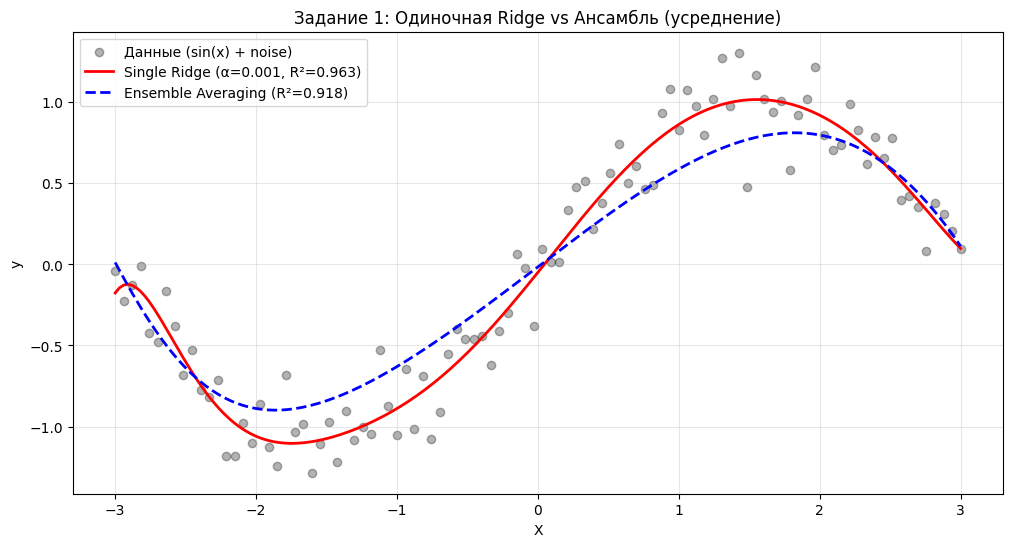


Задание 1:
Лучший alpha (CV): 0.0010
R² одиночной модели: 0.9635
R² ансамбля: 0.9184
Интерпретация: Ансамбль снижает дисперсию предсказаний за счёт усреднения моделей с разной силой регуляризации, что может улучшить обобщение на зашумленных данных.



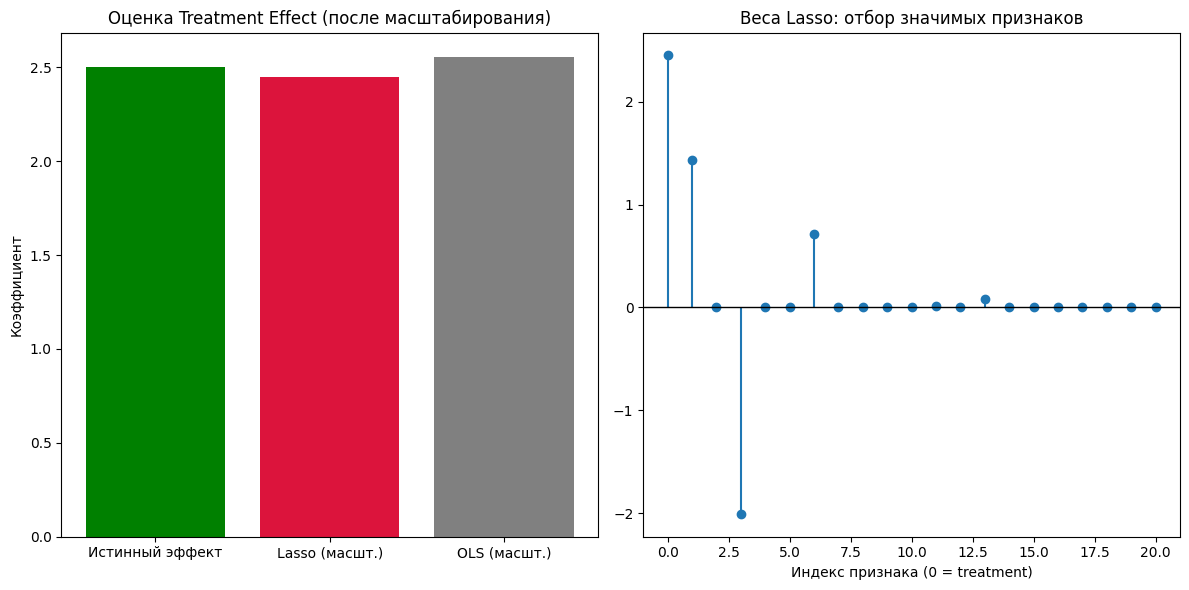


Задание 2:
Оптимальный alpha: 0.0693
Истинный эффект: 2.5
Lasso оценка эффекта (масшт.): 2.4504
OLS оценка эффекта (масшт.): 2.5570
Lasso обнулил 15 из 21 признаков.
Интерпретация: Lasso отбирает релевантные конфаундеры, снижая дисперсию оценки причинного эффекта. В отличие от OLS, Lasso уменьшает влияние шумовых признаков, что даёт более стабильную оценку.

Сбор мета-знаний из 30 синтетических датасетов...


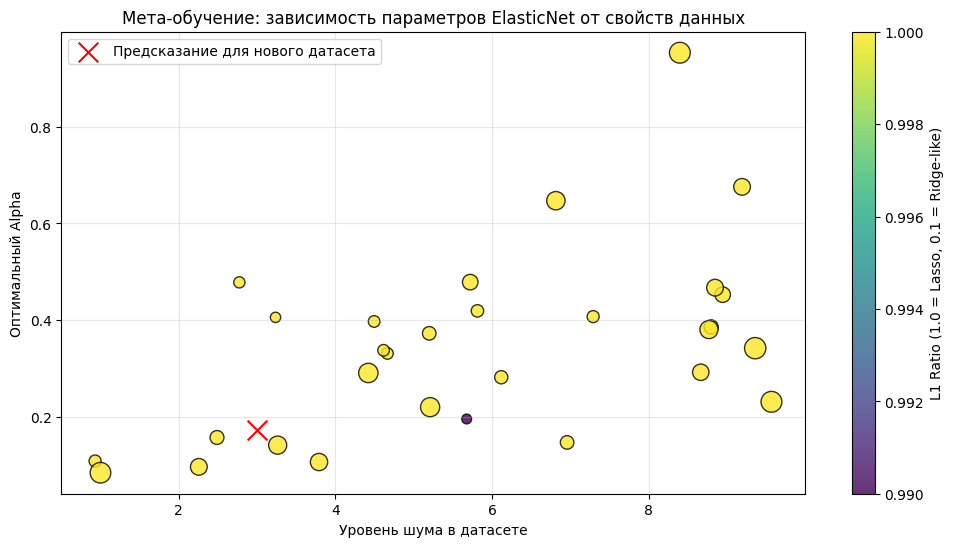


Задание 3:
Качество мета-модели (на отложенных мета-примерах):
  MAE для alpha: 0.1252
  MAE для l1_ratio: 0.0000
Рекомендация для нового датасета (40 признаков, 20% инф., шум=3.0):
  Alpha = 0.1716, L1_ratio = 1.0000
Интерпретация: Мета-обучение позволяет быстро предлагать гиперпараметры ElasticNet на основе характеристик новых данных, что экономит время на кросс-валидацию.

ОБЩИЙ ВЫВОД ПО ВАРИАНТУ 25:
1. Усреднение моделей Ridge с разными α снижает дисперсию и может улучшить качество предсказания по сравнению с одной оптимальной моделью.
2. Lasso помогает в причинном выводе, отсекая нерелевантные конфаундеры и уменьшая смещение оценки эффекта воздействия.
3. Мета-обучение позволяет предсказывать гиперпараметры ElasticNet по свойствам датасета, что ускоряет настройку модели на новых данных.
Ограничения методов: Lasso эффективен при разреженных признаках, Ridge – при плотных; мета-обучение требует разнообразной обучающей выборки датасетов.


In [ ]:
# Задание 1. Ridge + Model Averaging

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Генерация данных (воспроизводимость)
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Полиномиальные признаки и масштабирование
degree = 10
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
X_test_poly = scaler.transform(poly.transform(X_test))
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
X_plot_poly = scaler.transform(poly.transform(X_plot))

# Модель с оптимальным alpha (RidgeCV)
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_poly, y_train)
best_alpha = ridge_cv.alpha_
y_pred_single = ridge_cv.predict(X_test_poly)
r2_single = r2_score(y_test, y_pred_single)

# Ансамбль моделей (усреднение предсказаний)
ensemble_alphas = np.logspace(-2, 2, 10)
ensemble_preds_plot = []
ensemble_preds_test = []

for a in ensemble_alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_poly, y_train)
    ensemble_preds_plot.append(m.predict(X_plot_poly))
    ensemble_preds_test.append(m.predict(X_test_poly))

avg_pred_plot = np.mean(ensemble_preds_plot, axis=0)
avg_pred_test = np.mean(ensemble_preds_test, axis=0)
r2_ensemble = r2_score(y_test, avg_pred_test)

# Визуализация
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='black', alpha=0.3, label='Данные (sin(x) + noise)')
plt.plot(X_plot, ridge_cv.predict(X_plot_poly), 'r-', linewidth=2, label=f'Single Ridge (α={best_alpha:.3f}, R²={r2_single:.3f})')
plt.plot(X_plot, avg_pred_plot, 'b--', linewidth=2, label=f'Ensemble Averaging (R²={r2_ensemble:.3f})')
plt.title('Задание 1: Одиночная Ridge vs Ансамбль (усреднение)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nЗадание 1:")
print(f"Лучший alpha (CV): {best_alpha:.4f}")
print(f"R² одиночной модели: {r2_single:.4f}")
print(f"R² ансамбля: {r2_ensemble:.4f}")
print("Интерпретация: Ансамбль снижает дисперсию предсказаний за счёт усреднения моделей с разной силой регуляризации, что может улучшить обобщение на зашумленных данных.\n")

# Задание 2. Lasso + Causal Inference

from sklearn.linear_model import LassoCV, LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler

# Генерация данных с конфаундерами
np.random.seed(42)
n_samples = 300
n_confounders = 20

C = np.random.normal(0, 1, (n_samples, n_confounders))
true_effect = 2.5
treatment = 0.5 * C[:, 0] + 0.8 * C[:, 1] + np.random.normal(0, 0.5, n_samples)
y = true_effect * treatment + 1.5 * C[:, 0] - 2.0 * C[:, 2] + 0.8 * C[:, 5] + np.random.normal(0, 1, n_samples)

X = np.column_stack([treatment, C])

# Масштабирование (необходимо для корректной регуляризации)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lasso с кросс-валидацией
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
lasso_final = Lasso(alpha=lasso_cv.alpha_).fit(X_scaled, y)

# OLS на тех же масштабированных данных (для корректного сравнения коэффициентов)
ols_scaled = LinearRegression().fit(X_scaled, y)
est_effect_lasso = lasso_final.coef_[0]      # уже в одном масштабе
est_effect_ols = ols_scaled.coef_[0]

# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(['Истинный эффект', 'Lasso (масшт.)', 'OLS (масшт.)'],
        [true_effect, est_effect_lasso, est_effect_ols],
        color=['green', 'crimson', 'gray'])
plt.title('Оценка Treatment Effect (после масштабирования)')
plt.ylabel('Коэффициент')
plt.subplot(1, 2, 2)
plt.stem(lasso_final.coef_, basefmt=" ")
plt.axhline(0, color='black', linewidth=1)
plt.title('Веса Lasso: отбор значимых признаков')
plt.xlabel('Индекс признака (0 = treatment)')
plt.tight_layout()
plt.show()

print("\nЗадание 2:")
print(f"Оптимальный alpha: {lasso_cv.alpha_:.4f}")
print(f"Истинный эффект: {true_effect}")
print(f"Lasso оценка эффекта (масшт.): {est_effect_lasso:.4f}")
print(f"OLS оценка эффекта (масшт.): {est_effect_ols:.4f}")
print(f"Lasso обнулил {np.sum(lasso_final.coef_ == 0)} из {n_confounders+1} признаков.")
print("Интерпретация: Lasso отбирает релевантные конфаундеры, снижая дисперсию оценки причинного эффекта. В отличие от OLS, Lasso уменьшает влияние шумовых признаков, что даёт более стабильную оценку.\n")

# Задание 3. Elastic Net + Meta-learning

from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Сбор мета-знаний
def collect_meta_knowledge(n_datasets=30):
    meta_features = []   # [число признаков, доля информативных, уровень шума]
    meta_targets = []    # [лучший alpha, лучший l1_ratio]
    for i in range(n_datasets):
        np.random.seed(i)
        n_feats = np.random.randint(10, 50)
        inf_ratio = np.random.uniform(0.1, 0.5)
        noise_lvl = np.random.uniform(0.5, 10.0)
        X, y = make_regression(n_samples=150, n_features=n_feats,
                               n_informative=int(n_feats * inf_ratio),
                               noise=noise_lvl, random_state=i)
        X = StandardScaler().fit_transform(X)
        en_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, max_iter=5000, random_state=i)
        en_cv.fit(X, y)
        meta_features.append([n_feats, inf_ratio, noise_lvl])
        meta_targets.append([en_cv.alpha_, en_cv.l1_ratio_])
    return np.array(meta_features), np.array(meta_targets)

print("Сбор мета-знаний из 30 синтетических датасетов...")
X_meta, y_meta = collect_meta_knowledge(30)

# Обучение мета-модели (KNN) и оценка качества на отложенной выборке
from sklearn.model_selection import train_test_split
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(X_meta, y_meta, test_size=0.2, random_state=42)

meta_model = KNeighborsRegressor(n_neighbors=3)
meta_model.fit(X_meta_train, y_meta_train)

# Оценка качества предсказания параметров
alpha_pred_test = meta_model.predict(X_meta_test)[:, 0]
l1_pred_test = meta_model.predict(X_meta_test)[:, 1]

alpha_true_test = y_meta_test[:, 0]
l1_true_test = y_meta_test[:, 1]

alpha_mae = np.mean(np.abs(alpha_pred_test - alpha_true_test))
l1_mae = np.mean(np.abs(l1_pred_test - l1_true_test))

# Предсказание для нового датасета
new_data_desc = np.array([[40, 0.2, 3.0]])
predicted_params = meta_model.predict(new_data_desc)
alpha_p, l1_p = predicted_params[0]

# Визуализация
plt.figure(figsize=(12, 6))
sc = plt.scatter(X_meta[:, 2], y_meta[:, 0], c=y_meta[:, 1],
                 s=X_meta[:, 0]*5, cmap='viridis', alpha=0.8, edgecolors='black')
plt.colorbar(sc, label='L1 Ratio (1.0 = Lasso, 0.1 = Ridge-like)')
plt.xlabel('Уровень шума в датасете')
plt.ylabel('Оптимальный Alpha')
plt.title('Мета-обучение: зависимость параметров ElasticNet от свойств данных')
plt.grid(True, alpha=0.3)
plt.scatter(3.0, alpha_p, color='red', marker='x', s=200, label='Предсказание для нового датасета')
plt.legend()
plt.show()

print("\nЗадание 3:")
print(f"Качество мета-модели (на отложенных мета-примерах):")
print(f"  MAE для alpha: {alpha_mae:.4f}")
print(f"  MAE для l1_ratio: {l1_mae:.4f}")
print(f"Рекомендация для нового датасета (40 признаков, 20% инф., шум=3.0):")
print(f"  Alpha = {alpha_p:.4f}, L1_ratio = {l1_p:.4f}")
print("Интерпретация: Мета-обучение позволяет быстро предлагать гиперпараметры ElasticNet на основе характеристик новых данных, что экономит время на кросс-валидацию.")

# Общий вывод по варианту 25

print("\nОБЩИЙ ВЫВОД ПО ВАРИАНТУ 25:")
print("1. Усреднение моделей Ridge с разными α снижает дисперсию и может улучшить качество предсказания по сравнению с одной оптимальной моделью.")
print("2. Lasso помогает в причинном выводе, отсекая нерелевантные конфаундеры и уменьшая смещение оценки эффекта воздействия.")
print("3. Мета-обучение позволяет предсказывать гиперпараметры ElasticNet по свойствам датасета, что ускоряет настройку модели на новых данных.")
print("Ограничения методов: Lasso эффективен при разреженных признаках, Ridge – при плотных; мета-обучение требует разнообразной обучающей выборки датасетов.")
